In [3]:
train_path = '/content/drive/MyDrive/Colab/AIProj/train'
test_path = '/content/drive/MyDrive/Colab/AIProj/test'

In [4]:
import os

print("Train folders:", os.listdir(train_path))
print("Test folders:", os.listdir(test_path))

Train folders: ['.DS_Store', 'AD', 'CN', 'LMCI', 'EMCI', 'MCI']
Test folders: ['.DS_Store', 'LMCI', 'AD', 'EMCI', 'MCI', 'CN']


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

Found 883 images belonging to 5 classes.
Found 218 images belonging to 5 classes.
Found 195 images belonging to 5 classes.


In [6]:
print(train_generator.class_indices)

{'AD': 0, 'CN': 1, 'EMCI': 2, 'LMCI': 3, 'MCI': 4}


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

model1 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(5, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,501 (42.61 MB)

 Trainable params: 11,170,053 (42.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
history1 = model1.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 249s 9s/step - accuracy: 0.3352 - loss: 19.1538 - val_accuracy: 0.3119 - val_loss: 4.6833
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 151s 5s/step - accuracy: 0.4553 - loss: 1.6347 - val_accuracy: 0.1422 - val_loss: 17.3070
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 150s 5s/step - accuracy: 0.4575 - loss: 1.6740 - val_accuracy: 0.1422 - val_loss: 20.2738
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 160s 6s/step - accuracy: 0.4485 - loss: 1.5773 - val_accuracy: 0.1651 - val_loss: 17.6679
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 150s 5s/step - accuracy: 0.4473 - loss: 1.5982 - val_accuracy: 0.3899 - val_loss: 10.7418
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 152s 5s/step - accuracy: 0.4485 - loss: 1.5832 - val_accuracy: 0.4541 - val_loss: 7.4119
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 151s 5s/step - accuracy: 0.4451 - loss: 1.5799 - val_accuracy: 0.4587 - val_loss: 7.9596
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 163s 6s/step - accuracy: 0.4451 - loss: 1.5394 - val_accuracy: 0.431

In [9]:
test_loss1, test_acc1 = model1.evaluate(test_generator)

print("Custom CNN Test Accuracy:", test_acc1)
print("Custom CNN Test Loss:", test_loss1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 30s 4s/step - accuracy: 0.2718 - loss: 3.3619
Custom CNN Test Accuracy: 0.2717948853969574
Custom CNN Test Loss: 3.361870765686035


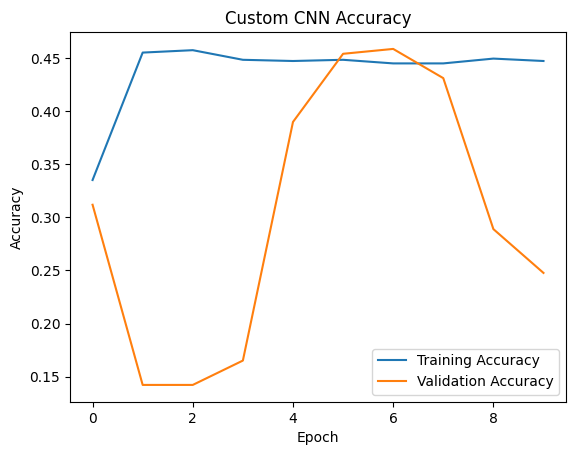

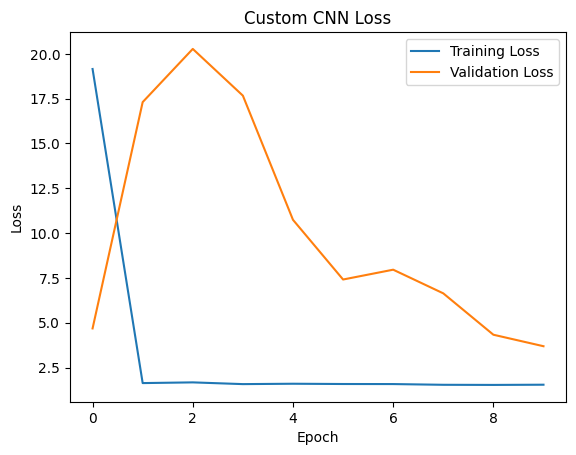

In [10]:
import matplotlib.pyplot as plt

plt.plot(history1.history['accuracy'], label='Training Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Custom CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history1.history['loss'], label='Training Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Custom CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_generator_aug = train_datagen_aug.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator_aug = train_datagen_aug.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 883 images belonging to 5 classes.
Found 218 images belonging to 5 classes.


In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [14]:
history2 = model1.fit(
    train_generator_aug,
    validation_data=val_generator_aug,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 164s 6s/step - accuracy: 0.4473 - loss: 1.5024 - val_accuracy: 0.1881 - val_loss: 3.1918
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 161s 6s/step - accuracy: 0.4485 - loss: 1.4928 - val_accuracy: 0.2844 - val_loss: 3.0009
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 164s 6s/step - accuracy: 0.4473 - loss: 1.4917 - val_accuracy: 0.3303 - val_loss: 2.7869
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 161s 6s/step - accuracy: 0.4462 - loss: 1.5852 - val_accuracy: 0.4037 - val_loss: 2.3022
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 164s 6s/step - accuracy: 0.4485 - loss: 1.4785 - val_accuracy: 0.4358 - val_loss: 2.3078
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 161s 6s/step - accuracy: 0.4451 - loss: 1.4749 - val_accuracy: 0.4495 - val_loss: 2.3199
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 201s 6s/step - accuracy: 0.4473 - loss: 1.4759 - val_accuracy: 0.4495 - val_loss: 2.4754


In [15]:
test_loss2, test_acc2 = model1.evaluate(test_generator)

print("Augmented CNN Test Accuracy:", test_acc2)
print("Augmented CNN Test Loss:", test_loss2)

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4359 - loss: 1.4873
Augmented CNN Test Accuracy: 0.43589743971824646
Augmented CNN Test Loss: 1.4872726202011108


In [16]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(5, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=predictions)

model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 262,917 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [17]:
history_resnet = model_resnet.fit(
    train_generator_aug,
    validation_data=val_generator_aug,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 203s 7s/step - accuracy: 0.3681 - loss: 1.6314 - val_accuracy: 0.4495 - val_loss: 1.4276
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 193s 7s/step - accuracy: 0.4439 - loss: 1.4360 - val_accuracy: 0.4495 - val_loss: 1.4098
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 194s 7s/step - accuracy: 0.4337 - loss: 1.4658 - val_accuracy: 0.4495 - val_loss: 1.4090
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 190s 7s/step - accuracy: 0.4326 - loss: 1.4401 - val_accuracy: 0.4495 - val_loss: 1.4209
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 204s 7s/step - accuracy: 0.4337 - loss: 1.4528 - val_accuracy: 0.4495 - val_loss: 1.4222
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 194s 7s/step - accuracy: 0.4405 - loss: 1.4452 - val_accuracy: 0.4495 - val_loss: 1.4234


In [18]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Freeze most layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Unfreeze last layers
for layer in base_model.layers[-30:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(5, activation='softmax')(x)

model_resnet = Model(inputs=base_model.input, outputs=predictions)

model_resnet.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_resnet.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,629 (90.98 MB)

 Trainable params: 14,713,093 (56.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

In [19]:
history_resnet = model_resnet.fit(
    train_generator_aug,
    validation_data=val_generator_aug,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 277s 10s/step - accuracy: 0.3964 - loss: 1.4980 - val_accuracy: 0.1835 - val_loss: 1.9237
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 257s 9s/step - accuracy: 0.4451 - loss: 1.4375 - val_accuracy: 0.1881 - val_loss: 1.7337
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 257s 9s/step - accuracy: 0.4202 - loss: 1.4537 - val_accuracy: 0.1881 - val_loss: 1.5756


In [20]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_mobile = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_mobile.layers:
    layer.trainable = False

x = base_mobile.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(5, activation='softmax')(x)

model_mobile = Model(inputs=base_mobile.input, outputs=output)

model_mobile.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_mobile.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:
history_mobile = model_mobile.fit(
    train_generator_aug,
    validation_data=val_generator_aug,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.2843 - loss: 1.9304 - val_accuracy: 0.4495 - val_loss: 1.4238
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.3296 - loss: 1.6461 - val_accuracy: 0.4450 - val_loss: 1.3902
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.3647 - loss: 1.5345 - val_accuracy: 0.4771 - val_loss: 1.3729
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 67s 2s/step - accuracy: 0.4111 - loss: 1.4825 - val_accuracy: 0.4587 - val_loss: 1.3726
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.4304 - loss: 1.4492 - val_accuracy: 0.4541 - val_loss: 1.3900
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.4292 - loss: 1.4398 - val_accuracy: 0.4633 - val_loss: 1.3744
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.4281 - loss: 1.4268 - val_accuracy: 0.4633 - val_loss: 1.3774


In [22]:
test_loss_mobile, test_acc_mobile = model_mobile.evaluate(test_generator)

print("MobileNetV2 Test Accuracy:", test_acc_mobile)
print("MobileNetV2 Test Loss:", test_loss_mobile)

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 975ms/step - accuracy: 0.4308 - loss: 1.4138
MobileNetV2 Test Accuracy: 0.4307692348957062
MobileNetV2 Test Loss: 1.4137790203094482


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 816ms/step
              precision    recall  f1-score   support

          AD       0.00      0.00      0.00        26
          CN       0.44      0.98      0.61        87
        EMCI       0.00      0.00      0.00        36
        LMCI       0.00      0.00      0.00        11
         MCI       0.00      0.00      0.00        35

    accuracy                           0.44       195
   macro avg       0.09      0.20      0.12       195
weighted avg       0.20      0.44      0.27       195



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


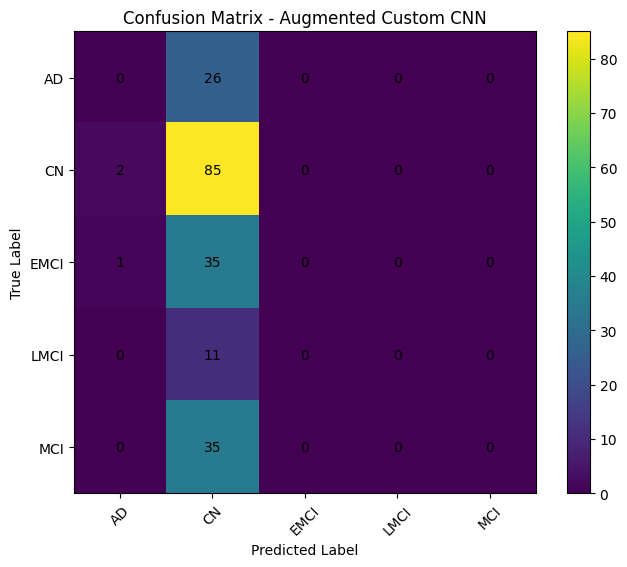

In [23]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

test_generator.reset()

y_true = test_generator.classes
y_pred_probs = model1.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm)
plt.title("Confusion Matrix - Augmented Custom CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [24]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.5224137931034483), 1: np.float64(0.4470886075949367), 2: np.float64(1.076829268292683), 3: np.float64(3.6040816326530614), 4: np.float64(1.110691823899371)}


In [25]:
history2 = model1.fit(
    train_generator_aug,
    validation_data=val_generator_aug,
    epochs=10,
    callbacks=[early_stop],
    class_weight=class_weights
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 167s 6s/step - accuracy: 0.4473 - loss: 1.6310 - val_accuracy: 0.4450 - val_loss: 2.2740
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 161s 6s/step - accuracy: 0.4485 - loss: 1.6489 - val_accuracy: 0.4587 - val_loss: 2.3011
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 165s 6s/step - accuracy: 0.4496 - loss: 1.6474 - val_accuracy: 0.4541 - val_loss: 2.2880


In [26]:
plt.savefig("confusion_matrix.png")

<Figure size 640x480 with 0 Axes>

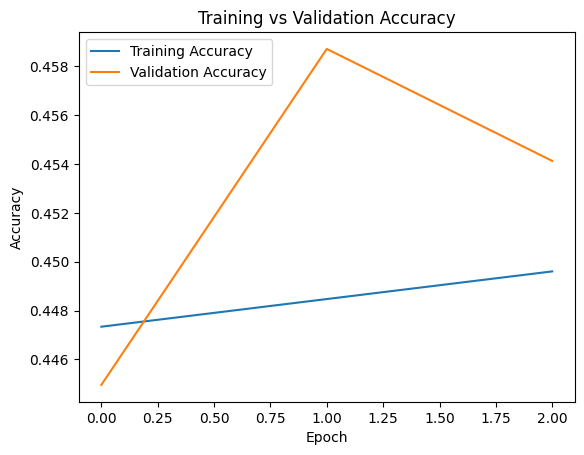

In [27]:
plt.figure()
plt.plot(history2.history['accuracy'], label='Training Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.savefig("accuracy_plot.png")
plt.show()

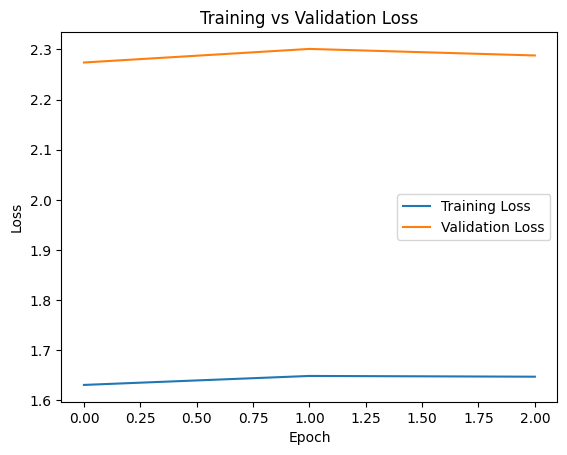

In [28]:
plt.figure()
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig("loss_plot.png")
plt.show()